In [1]:
import torch
from manify.curvature_estimation.delta_hyperbolicity import delta_hyperbolicity
import networkx as nx 
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import shortest_path
import numpy as np
import pydot

In [2]:
# 1) One-hot data/identity matrix

n = 100
X = torch.eye(n)
# Calculate Euclidean distance matrix
dismat = torch.cdist(X, X)

delta_hyperbolicity(dismat)

0.0

In [3]:
# 2) Leaf node deltas

In [4]:
n_nodes = 1000
max_children = 4

In [5]:
# Create tree

G = nx.Graph()

G.add_nodes_from(range(n_nodes))

# Start with node 0 as the root
remaining_nodes = set(range(1, n_nodes))
connected_nodes = {0}

while remaining_nodes:
    # Pick a random connected node to be a parent
    parent = np.random.choice(list(connected_nodes))
    
    # Determine number of children for this parent (1 to max_children)
    n_children = min(np.random.randint(1, max_children+1), len(remaining_nodes))
    
    # Randomly select children from remaining nodes
    children = np.random.choice(list(remaining_nodes), size=n_children, replace=False)
    
    # Add edges between parent and children
    for child in children:
        G.add_edge(parent, child)
        connected_nodes.add(child)
        remaining_nodes.remove(child)

leaf_nodes = [node for node, degree in G.degree() if degree == 1]
root_node = 0

adj_matrix = nx.to_numpy_array(G)

# Calculate shortest paths between all nodes
dist_matrix_full = shortest_path(adj_matrix, directed=False)

leaf_indices = np.array(leaf_nodes)
leaf_dismat = torch.from_numpy(dist_matrix_full[np.ix_(leaf_indices, leaf_indices)])

delta_hyperbolicity(leaf_dismat)

0.0

In [6]:
from manify.manifolds import ProductManifold
from manify.embedders.coordinate_learning import train_coords

In [7]:
CURVATURE = -1
DIMENSION = 7

pm = ProductManifold(device='cuda',signature=[(CURVATURE, DIMENSION)])
leaf_dismat = leaf_dismat.to(device='cuda')
tree_emb, losses = train_coords(pm, leaf_dismat, device='cuda', training_iterations=80)

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
dismat = torch.cdist(tree_emb,tree_emb)
delta_hyperbolicity(dismat)

NameError: name 'tree_emb' is not defined

In [ ]:
# 3) Sampling from the wrapped normal

In [ ]:
# Baseline (normal dim and curvature)
CURVATURE = -1
DIMENSION = 5

hyperbolic_manifold = ProductManifold(signature=[(CURVATURE,DIMENSION)], device="cpu")

n_samples = 100
hyperbolic_points, _ = hyperbolic_manifold.sample(
    z_mean=torch.stack([hyperbolic_manifold.mu0] * n_samples),
    sigma_factorized=[torch.stack([torch.eye(DIMENSION)] * n_samples)]
)

hyperbolic_distances = hyperbolic_manifold.pdist(hyperbolic_points)

euclidean_distances = torch.cdist(hyperbolic_points, hyperbolic_points, p=2)

hyperbolic_delta = delta_hyperbolicity(hyperbolic_distances)
euclidean_delta = delta_hyperbolicity(euclidean_distances)

print(f"Hyperbolic delta: {hyperbolic_delta:.6f}")
print(f"Euclidean delta: {euclidean_delta:.6f}")

Hyperbolic delta: 0.165356
Euclidean delta: 0.173687


Hyperbolic delta for K=-3.0: 0.113361
Euclidean delta for K=-3.0: 0.246502
Hyperbolic delta for K=-2.7272727272727275: 0.117874
Euclidean delta for K=-2.7272727272727275: 0.241529
Hyperbolic delta for K=-2.4545454545454546: 0.111516
Euclidean delta for K=-2.4545454545454546: 0.096889
Hyperbolic delta for K=-2.1818181818181817: 0.112934
Euclidean delta for K=-2.1818181818181817: 0.250521
Hyperbolic delta for K=-1.9090909090909092: 0.118430
Euclidean delta for K=-1.9090909090909092: 0.098770
Hyperbolic delta for K=-1.6363636363636365: 0.142658
Euclidean delta for K=-1.6363636363636365: 0.330862
Hyperbolic delta for K=-1.3636363636363638: 0.174166
Euclidean delta for K=-1.3636363636363638: 0.344249
Hyperbolic delta for K=-1.090909090909091: 0.165777
Euclidean delta for K=-1.090909090909091: 0.255629
Hyperbolic delta for K=-0.8181818181818183: 0.204309
Euclidean delta for K=-0.8181818181818183: 0.314279
Hyperbolic delta for K=-0.5454545454545459: 0.208069
Euclidean delta for K=-0.545454545

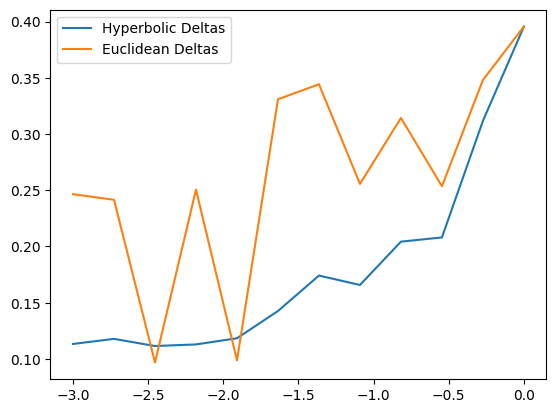

In [ ]:
# What if we modify the curvature?

Ks = np.linspace(-3,0,12)
n_samples = 100

h_deltas = []
e_deltas = []

for K in Ks:
    hyperbolic_manifold = ProductManifold(signature=[(K,DIMENSION)], device="cpu")

    hyperbolic_points, _ = hyperbolic_manifold.sample(
        z_mean=torch.stack([hyperbolic_manifold.mu0] * n_samples),
        sigma_factorized=[torch.stack([torch.eye(DIMENSION)] * n_samples)]
    )

    hyperbolic_distances = hyperbolic_manifold.pdist(hyperbolic_points)

    euclidean_distances = torch.cdist(hyperbolic_points, hyperbolic_points, p=2)

    hyperbolic_delta = delta_hyperbolicity(hyperbolic_distances)
    euclidean_delta = delta_hyperbolicity(euclidean_distances)

    h_deltas.append(hyperbolic_delta)
    e_deltas.append(euclidean_delta)

    print(f"Hyperbolic delta for K={K}: {hyperbolic_delta:.6f}")
    print(f"Euclidean delta for K={K}: {euclidean_delta:.6f}")

plt.plot(Ks,h_deltas, label="Hyperbolic Deltas")
plt.plot(Ks,e_deltas, label='Euclidean Deltas')
plt.legend()
plt.show()

In [8]:
from manify.curvature_estimation.delta_hyperbolicity import delta_full

In [11]:
# What if we look at the mean delta hyperbolicities on the wrapped normal while modifying curvature?

Ks = np.linspace(-3,0,12)
n_samples = 100

h_deltas = []
e_deltas = []

for K in Ks:
    hyperbolic_manifold = ProductManifold(signature=[(K,DIMENSION)], device="cpu")

    hyperbolic_points, _ = hyperbolic_manifold.sample(
        z_mean=torch.stack([hyperbolic_manifold.mu0] * n_samples),
        sigma_factorized=[torch.stack([torch.eye(DIMENSION)] * n_samples)]
    )

    hyperbolic_distances = hyperbolic_manifold.pdist(hyperbolic_points)

    euclidean_distances = torch.cdist(hyperbolic_points, hyperbolic_points, p=2)

    hyperbolic_delta = delta_full(hyperbolic_distances).mean().item()
    euclidean_delta = delta_full(euclidean_distances).mean().item()

    h_deltas.append(hyperbolic_delta)
    e_deltas.append(euclidean_delta)

    print(f"Hyperbolic delta for K={K}: {hyperbolic_delta:.6f}")
    print(f"Euclidean delta for K={K}: {euclidean_delta:.6f}")

Hyperbolic delta for K=-3.0: -0.128998
Euclidean delta for K=-3.0: -13.264698
Hyperbolic delta for K=-2.7272727272727275: -0.123026
Euclidean delta for K=-2.7272727272727275: -11.207640
Hyperbolic delta for K=-2.4545454545454546: -0.150653
Euclidean delta for K=-2.4545454545454546: -5.559382
Hyperbolic delta for K=-2.1818181818181817: -0.154818
Euclidean delta for K=-2.1818181818181817: -5.105425
Hyperbolic delta for K=-1.9090909090909092: -0.173023
Euclidean delta for K=-1.9090909090909092: -4.796909
Hyperbolic delta for K=-1.6363636363636365: -0.168157
Euclidean delta for K=-1.6363636363636365: -2.187038
Hyperbolic delta for K=-1.3636363636363638: -0.172725
Euclidean delta for K=-1.3636363636363638: -1.597832
Hyperbolic delta for K=-1.090909090909091: -0.185559
Euclidean delta for K=-1.090909090909091: -1.190650
Hyperbolic delta for K=-0.8181818181818183: -0.214840
Euclidean delta for K=-0.8181818181818183: -1.191826
Hyperbolic delta for K=-0.5454545454545459: -0.251388
Euclidean del

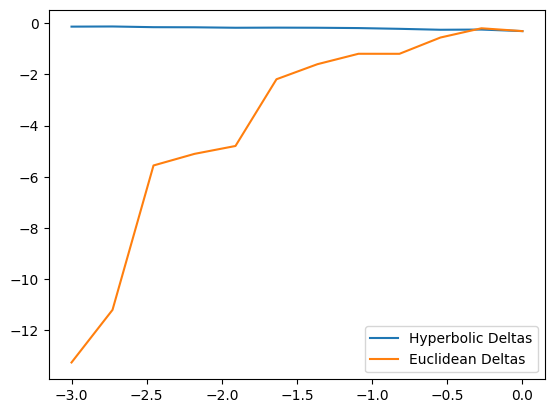

In [12]:
plt.plot(Ks,h_deltas, label="Hyperbolic Deltas")
plt.plot(Ks,e_deltas, label='Euclidean Deltas')
plt.legend()
plt.show()

In [14]:
from manify.curvature_estimation.delta_hyperbolicity import rel_deltas_full

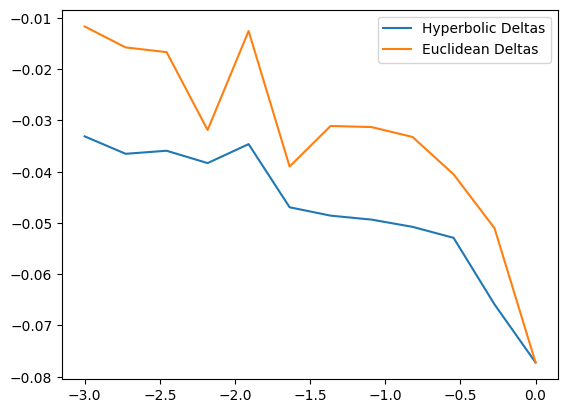

In [ ]:
# What if we look at the mean RELATIVE delta hyperbolicities on the wrapped normal while modifying curvature?

Ks = np.linspace(-3,0,12)
n_samples = 100

h_deltas = []
e_deltas = []

for K in Ks:
    hyperbolic_manifold = ProductManifold(signature=[(K,DIMENSION)], device="cpu")

    hyperbolic_points, _ = hyperbolic_manifold.sample(
        z_mean=torch.stack([hyperbolic_manifold.mu0] * n_samples),
        sigma_factorized=[torch.stack([torch.eye(DIMENSION)] * n_samples)]
    )

    hyperbolic_distances = hyperbolic_manifold.pdist(hyperbolic_points)

    euclidean_distances = torch.cdist(hyperbolic_points, hyperbolic_points, p=2)

    hyperbolic_delta = rel_deltas_full(hyperbolic_distances).mean().item()
    euclidean_delta = rel_deltas_full(euclidean_distances).mean().item()

    h_deltas.append(hyperbolic_delta)
    e_deltas.append(euclidean_delta)

plt.plot(Ks,h_deltas, label="Hyperbolic Deltas")
plt.plot(Ks,e_deltas, label='Euclidean Deltas')
plt.legend()
plt.show()

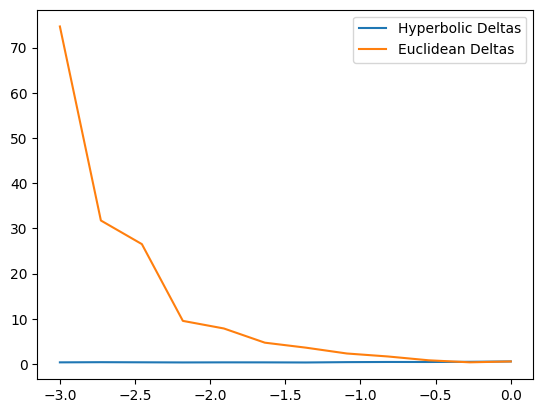

In [23]:
# Is there a relationship between variance and curvature?
# What if we look at the mean RELATIVE delta hyperbolicities on the wrapped normal while modifying curvature?

Ks = np.linspace(-3,0,12)
n_samples = 100

h_deltas = []
e_deltas = []

for K in Ks:
    hyperbolic_manifold = ProductManifold(signature=[(K,DIMENSION)], device="cpu")

    hyperbolic_points, _ = hyperbolic_manifold.sample(
        z_mean=torch.stack([hyperbolic_manifold.mu0] * n_samples),
        sigma_factorized=[torch.stack([torch.eye(DIMENSION)] * n_samples)]
    )

    hyperbolic_distances = hyperbolic_manifold.pdist(hyperbolic_points)

    euclidean_distances = torch.cdist(hyperbolic_points, hyperbolic_points, p=2)

    hyperbolic_delta = delta_full(hyperbolic_distances).std().item()
    euclidean_delta = delta_full(euclidean_distances).std().item()

    h_deltas.append(hyperbolic_delta)
    e_deltas.append(euclidean_delta)

plt.plot(Ks,h_deltas, label="Hyperbolic Deltas")
plt.plot(Ks,e_deltas, label='Euclidean Deltas')
plt.legend()
plt.show()